In [39]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.optimize import nnls

## Data Cleaning

Aggregate each site to hourly average load. Keep sites only when their hourly missing rate is less than or equal to 5%, and exclude any site that ever has a negative hourly load.

Normalize each cleaned site time series so every site has the same mean hourly load.

In [3]:


COMBINED_PATH = Path("../src/data/sites/calculated_overall_timeseries.parquet")
LOAD_COLUMN = "calculated_overall_power"
MISSING_RATE_THRESHOLD = 0.05


calculated_overall_timeseries = pd.read_parquet(COMBINED_PATH)
calculated_overall_timeseries["min_t"] = pd.to_datetime(calculated_overall_timeseries["min_t"])

# Hourly load is the average of all measurements within each site-hour.
calculated_overall_hourly = (
    calculated_overall_timeseries
    .set_index("min_t")
    .groupby("ee_site_id")
    .resample("h")[LOAD_COLUMN]
    .mean()
    .reset_index()
)
calculated_overall_hourly["is_negative_load"] = calculated_overall_hourly[LOAD_COLUMN] < 0

hourly_quality_summary = (
    calculated_overall_hourly
    .groupby("ee_site_id")
    .agg(
        start_time=("min_t", "min"),
        end_time=("min_t", "max"),
        observed_hours=(LOAD_COLUMN, "count"),
        negative_hours=("is_negative_load", "sum"),
    )
    .reset_index()
)
hourly_quality_summary["expected_hours"] = (
    (hourly_quality_summary["end_time"] - hourly_quality_summary["start_time"]).dt.total_seconds() / 3600
).astype(int) + 1
hourly_quality_summary["missing_hours"] = (
    hourly_quality_summary["expected_hours"] - hourly_quality_summary["observed_hours"]
)
hourly_quality_summary["missing_rate"] = (
    hourly_quality_summary["missing_hours"] / hourly_quality_summary["expected_hours"]
)
hourly_quality_summary["has_negative_load"] = hourly_quality_summary["negative_hours"] > 0

overall_missing_rate = (
    hourly_quality_summary["missing_hours"].sum()
    / hourly_quality_summary["expected_hours"].sum()
)
print(f"Overall hourly missing rate: {overall_missing_rate:.2%}")

kept_site_ids = hourly_quality_summary.loc[
    (hourly_quality_summary["missing_rate"] <= MISSING_RATE_THRESHOLD)
    & (~hourly_quality_summary["has_negative_load"]),
    "ee_site_id",
]

calculated_overall_hourly_kept = (
    calculated_overall_hourly
    .loc[
        calculated_overall_hourly["ee_site_id"].isin(kept_site_ids)
        & calculated_overall_hourly[LOAD_COLUMN].notna(),
        ["ee_site_id", "min_t", LOAD_COLUMN],
    ]
    .copy()
)

n_sites_total = hourly_quality_summary["ee_site_id"].nunique()
n_sites_missing_removed = (
    (hourly_quality_summary["missing_rate"] > MISSING_RATE_THRESHOLD)
    & (~hourly_quality_summary["has_negative_load"])
).sum()
n_sites_negative_removed = hourly_quality_summary["has_negative_load"].sum()

print(
    f"Keeping {len(kept_site_ids):,} / {n_sites_total:,} sites with missing rate <= "
    f"{MISSING_RATE_THRESHOLD:.0%} and no negative hourly loads."
)
print(f"Excluded {int(n_sites_negative_removed):,} sites that ever contain negative hourly load.")
print(f"Excluded {int(n_sites_missing_removed):,} additional sites for missing rate > {MISSING_RATE_THRESHOLD:.0%}.")



Overall hourly missing rate: 3.69%
Keeping 220 / 259 sites with missing rate <= 5% and no negative hourly loads.
Excluded 2 sites that ever contain negative hourly load.
Excluded 37 additional sites for missing rate > 5%.


In [4]:
site_mean_load = calculated_overall_hourly_kept.groupby("ee_site_id")[LOAD_COLUMN].transform("mean")
target_mean_load = calculated_overall_hourly_kept[LOAD_COLUMN].mean()

calculated_overall_hourly_normalized = calculated_overall_hourly_kept.copy()
calculated_overall_hourly_normalized[LOAD_COLUMN] = (
    calculated_overall_hourly_normalized[LOAD_COLUMN] / site_mean_load * target_mean_load
)

print(f"Normalized {calculated_overall_hourly_normalized['ee_site_id'].nunique():,} site time series to mean load {target_mean_load:.3f}.")


Normalized 220 site time series to mean load 1.462.


## PCA Analysis Plan

Next, compare multiple feature representations of the normalized hourly load profiles to see which view is explained most compactly by PCA. The goal is to identify whether PCA captures the main variation better from raw annual shape, daily summaries, weekly summaries, or other aggregated profile features.

Candidate feature views:

- **Direct annual hourly profile:** one feature per hour across the year, preserving the full chronological load shape.
- **Daily profile features:** aggregate each day into summary statistics such as daily mean, peak, minimum, and load range.
- **Weekly profile features:** aggregate daily or hourly behavior by week to capture seasonal and weekly-scale structure.
- **Typical-day or average-day profile:** summarize each site by its average 24-hour load shape, emphasizing diurnal behavior.
- **Hybrid summary features:** combine daily, weekly, and shape statistics to test whether lower-dimensional engineered features explain variation better than the raw time series.

For each feature view, fit PCA and compare explained variance across components, especially cumulative variance in the first few principal components.

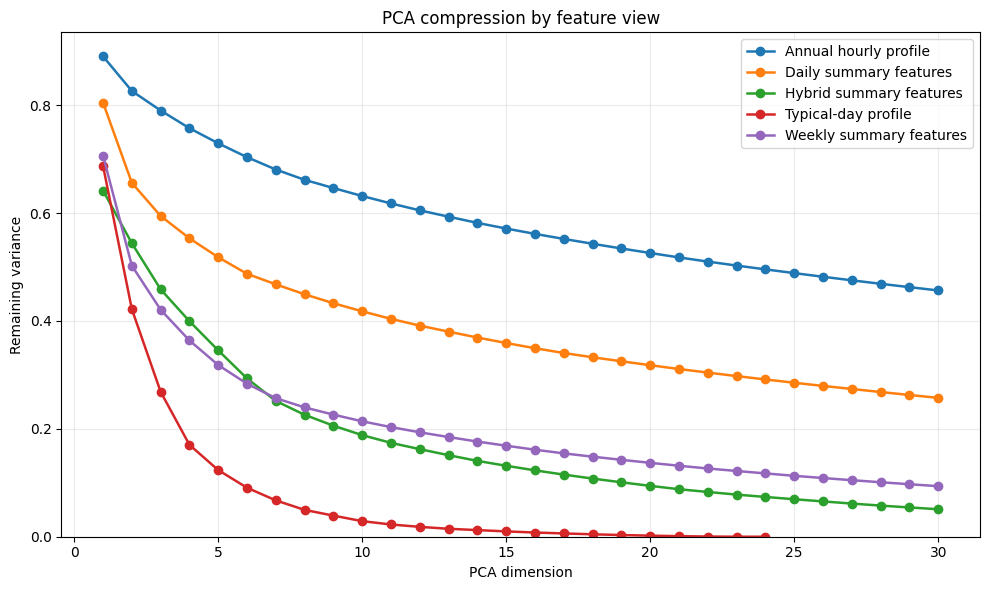

In [30]:

PCA_MAX_COMPONENTS = 30


def _fill_feature_matrix(features):
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.dropna(axis=1, how="all")
    return features.fillna(features.mean())


def _flatten_columns(df):
    df = df.copy()
    df.columns = [f"{left}_{right}" for left, right in df.columns]
    return df


def _fit_pca_summary(name, features):
    features = _fill_feature_matrix(features)
    n_components = min(PCA_MAX_COMPONENTS, features.shape[0] - 1, features.shape[1])
    X = StandardScaler().fit_transform(features)
    pca = PCA(n_components=n_components, random_state=32)
    pca.fit(X)
    cumulative_explained = np.cumsum(pca.explained_variance_ratio_)

    return pd.DataFrame(
        {
            "feature_view": name,
            "pca_dimension": np.arange(1, n_components + 1),
            "explained_variance": cumulative_explained,
            "remaining_variance": 1 - cumulative_explained,
            "n_features": features.shape[1],
            "n_sites": features.shape[0],
        }
    )


pca_input = calculated_overall_hourly_normalized.copy()
annual_start = pca_input["min_t"].min().floor("h")
annual_end = pca_input["min_t"].max().floor("h")
annual_hours = pd.date_range(annual_start, annual_end, freq="h")

pca_input = pca_input[pca_input["min_t"].between(annual_start, annual_end)].copy()
hourly_matrix = (
    pca_input
    .pivot_table(index="ee_site_id", columns="min_t", values=LOAD_COLUMN, aggfunc="mean")
    .reindex(columns=annual_hours)
    .sort_index(axis=1)
)
hourly_matrix = hourly_matrix.interpolate(axis=1, limit_direction="both")
hourly_matrix = hourly_matrix.T.fillna(hourly_matrix.mean(axis=1)).T

annual_hourly_features = hourly_matrix.copy()

typical_day_features = (
    pca_input.assign(hour_of_day=pca_input["min_t"].dt.hour)
    .pivot_table(index="ee_site_id", columns="hour_of_day", values=LOAD_COLUMN, aggfunc="mean")
    .reindex(columns=range(24))
)
typical_day_features.columns = [f"hour_{hour:02d}" for hour in typical_day_features.columns]

daily_stats = (
    pca_input.assign(date=pca_input["min_t"].dt.date)
    .groupby(["ee_site_id", "date"])[LOAD_COLUMN]
    .agg(daily_mean="mean", daily_peak="max", daily_min="min", daily_std="std")
)
daily_stats["daily_range"] = daily_stats["daily_peak"] - daily_stats["daily_min"]
daily_features = _flatten_columns(daily_stats.unstack("date"))

weekly_stats = (
    pca_input.assign(week_index=((pca_input["min_t"] - annual_start).dt.days // 7).astype(int))
    .groupby(["ee_site_id", "week_index"])[LOAD_COLUMN]
    .agg(weekly_mean="mean", weekly_peak="max", weekly_min="min", weekly_std="std")
)
weekly_stats["weekly_range"] = weekly_stats["weekly_peak"] - weekly_stats["weekly_min"]
weekly_features = _flatten_columns(weekly_stats.unstack("week_index"))

hybrid_features = pd.concat(
    [
        typical_day_features.add_prefix("typical_day_"),
        weekly_features.filter(like="weekly_mean_").add_prefix("weekly_"),
    ],
    axis=1,
)

feature_views = {
    "Annual hourly profile": annual_hourly_features,
    "Daily summary features": daily_features,
    "Weekly summary features": weekly_features,
    "Typical-day profile": typical_day_features,
    "Hybrid summary features": hybrid_features,
}

pca_comparison = pd.concat(
    [_fit_pca_summary(name, features) for name, features in feature_views.items()],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 6))
for feature_view, view_df in pca_comparison.groupby("feature_view"):
    ax.plot(
        view_df["pca_dimension"],
        view_df["remaining_variance"],
        marker="o",
        linewidth=1.8,
        label=feature_view,
    )

ax.set_title("PCA compression by feature view")
ax.set_xlabel("PCA dimension")
ax.set_ylabel("Remaining variance")
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()



## Typical-Day Clustering

Use the typical-day representation for clustering because it is the most compactly explained by PCA. Rebuild the typical-day feature matrix in this section so clustering can run without rerunning the PCA comparison section.

In [20]:
typical_day_features_for_clustering = (
    calculated_overall_hourly_normalized
    .assign(hour_of_day=calculated_overall_hourly_normalized["min_t"].dt.hour)
    .pivot_table(index="ee_site_id", columns="hour_of_day", values=LOAD_COLUMN, aggfunc="mean")
    .reindex(columns=range(24))
)
typical_day_features_for_clustering.columns = [
    f"hour_{hour:02d}" for hour in typical_day_features_for_clustering.columns
]
typical_day_features_for_clustering = typical_day_features_for_clustering.fillna(
    typical_day_features_for_clustering.mean()
)

print(
    f"Built typical-day features for {typical_day_features_for_clustering.shape[0]:,} sites "
    f"with {typical_day_features_for_clustering.shape[1]:,} hourly features."
)


Built typical-day features for 218 sites with 24 hourly features.


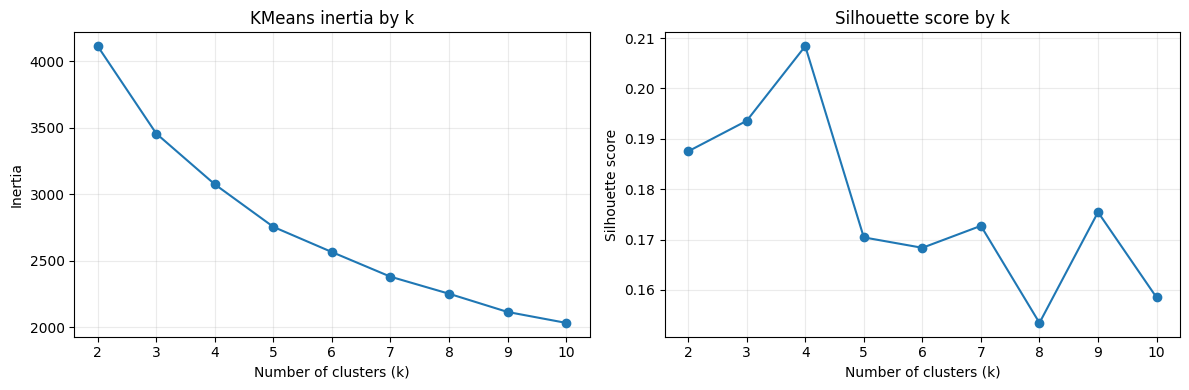

In [26]:


TYPICAL_DAY_PCA_COMPONENTS = 10
TYPICAL_DAY_K_VALUES = range(2, 11)

typical_day_scaler = StandardScaler()
X_typical_day = typical_day_scaler.fit_transform(typical_day_features_for_clustering)

typical_day_pca = PCA(n_components=TYPICAL_DAY_PCA_COMPONENTS, random_state=32)
typical_day_pca_scores = typical_day_pca.fit_transform(X_typical_day)

typical_day_k_diagnostics = []
for k in TYPICAL_DAY_K_VALUES:
    model = KMeans(n_clusters=k, random_state=32, n_init=20)
    labels = model.fit_predict(typical_day_pca_scores)
    typical_day_k_diagnostics.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(typical_day_pca_scores, labels),
        }
    )

typical_day_k_diagnostics = pd.DataFrame(typical_day_k_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(typical_day_k_diagnostics["k"], typical_day_k_diagnostics["inertia"], marker="o")
axes[0].set_title("KMeans inertia by k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.25)

axes[1].plot(typical_day_k_diagnostics["k"], typical_day_k_diagnostics["silhouette_score"], marker="o")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [27]:
TYPICAL_DAY_N_CLUSTERS = 4

typical_day_cluster_model = KMeans(
    n_clusters=TYPICAL_DAY_N_CLUSTERS,
    random_state=32,
    n_init=20,
)
typical_day_cluster_labels = typical_day_cluster_model.fit_predict(typical_day_pca_scores)

typical_day_cluster_assignments = pd.DataFrame(
    {
        "ee_site_id": typical_day_features_for_clustering.index,
        "typical_day_cluster": typical_day_cluster_labels,
    }
).set_index("ee_site_id")

print(
    f"Clustered {len(typical_day_cluster_assignments):,} sites using "
    f"{TYPICAL_DAY_PCA_COMPONENTS} typical-day PCA dimensions and "
    f"{TYPICAL_DAY_N_CLUSTERS} clusters."
)
display(typical_day_cluster_assignments["typical_day_cluster"].value_counts().sort_index().rename("n_sites"))

Clustered 218 sites using 10 typical-day PCA dimensions and 4 clusters.


typical_day_cluster
0      8
1    106
2     55
3     49
Name: n_sites, dtype: int64

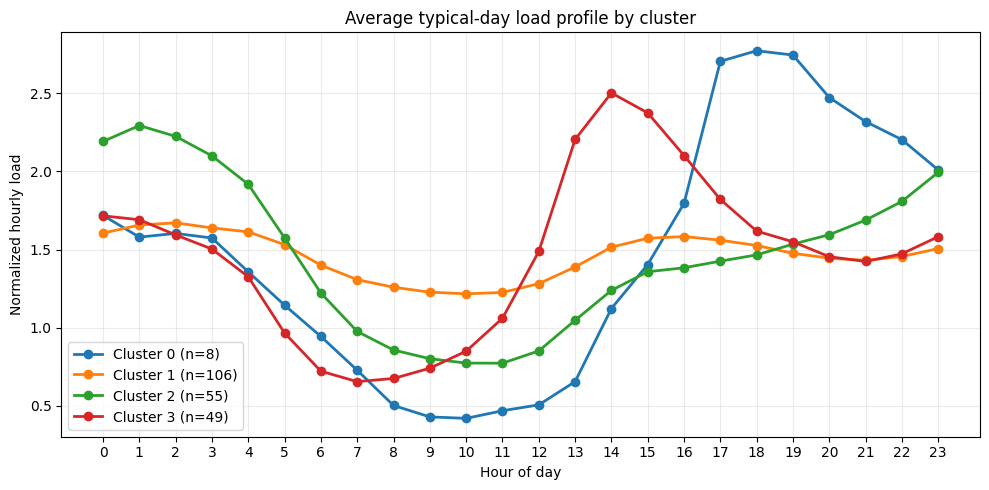

In [28]:
typical_day_cluster_profiles = typical_day_features_for_clustering.join(typical_day_cluster_assignments)
cluster_mean_profiles = typical_day_cluster_profiles.groupby("typical_day_cluster").mean()
cluster_site_counts = typical_day_cluster_assignments["typical_day_cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
hours = np.arange(24)
for cluster_id, profile in cluster_mean_profiles.iterrows():
    ax.plot(
        hours,
        profile.values,
        marker="o",
        linewidth=2,
        label=f"Cluster {cluster_id} (n={cluster_site_counts.loc[cluster_id]})",
    )

ax.set_title("Average typical-day load profile by cluster")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Normalized hourly load")
ax.set_xticks(hours)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

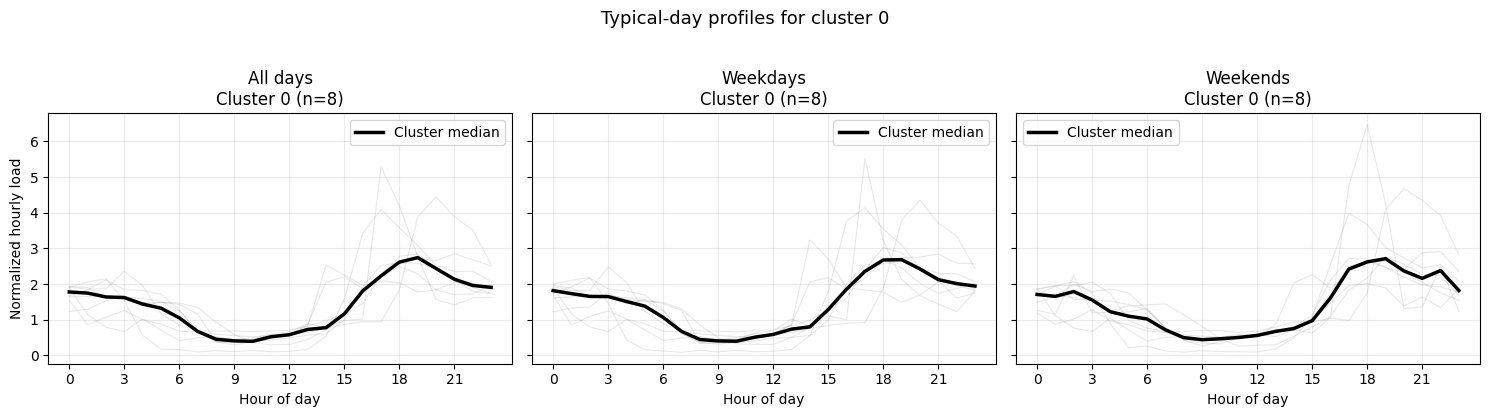

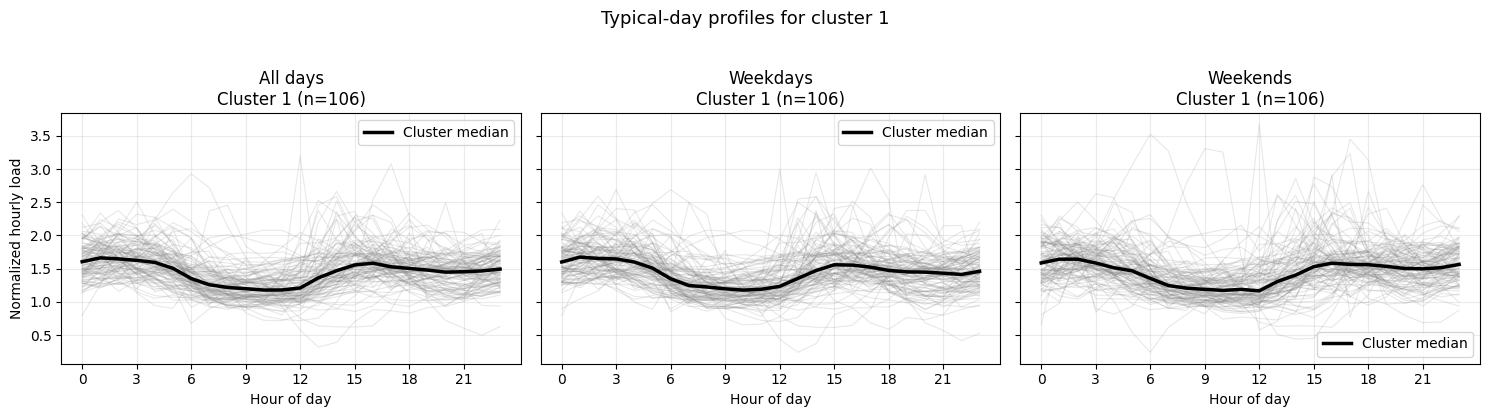

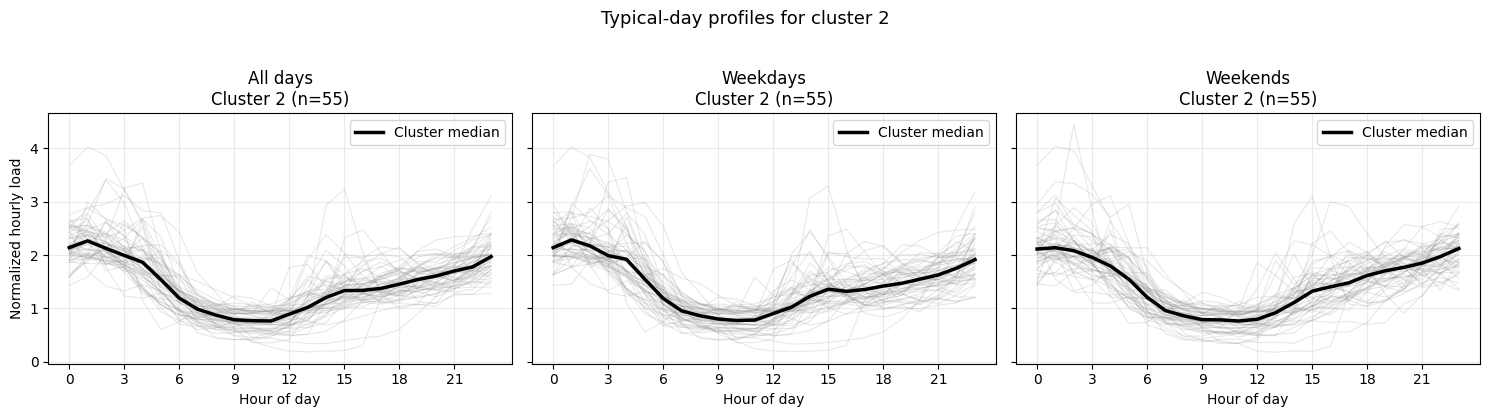

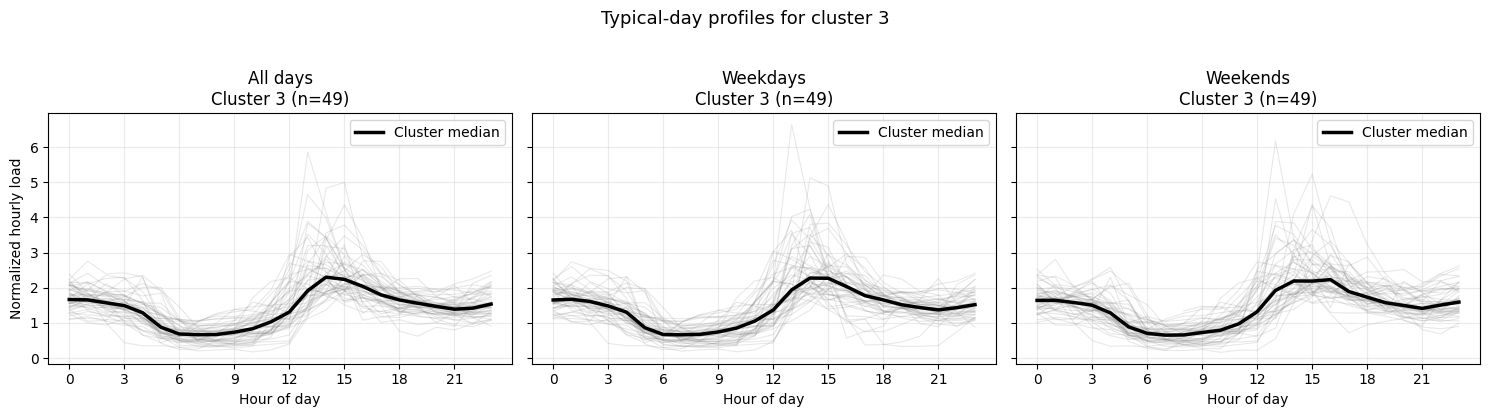

In [65]:
typical_day_profile_source = calculated_overall_hourly_normalized.copy()
typical_day_profile_source["hour_of_day"] = typical_day_profile_source["min_t"].dt.hour
typical_day_profile_source["is_weekend"] = typical_day_profile_source["min_t"].dt.dayofweek >= 5


def build_hourly_profile_by_site(data):
    profiles = (
        data
        .pivot_table(index="ee_site_id", columns="hour_of_day", values=LOAD_COLUMN, aggfunc="mean")
        .reindex(columns=range(24))
    )
    profiles.columns = [f"hour_{hour:02d}" for hour in profiles.columns]
    return profiles


all_day_profiles = build_hourly_profile_by_site(typical_day_profile_source)
weekday_profiles = build_hourly_profile_by_site(typical_day_profile_source[~typical_day_profile_source["is_weekend"]])
weekend_profiles = build_hourly_profile_by_site(typical_day_profile_source[typical_day_profile_source["is_weekend"]])

profile_sets = [
    ("All days", all_day_profiles),
    ("Weekdays", weekday_profiles),
    ("Weekends", weekend_profiles),
]

cluster_ids = sorted(typical_day_cluster_assignments["typical_day_cluster"].unique())
hours = np.arange(24)

for cluster_id in cluster_ids:
    site_ids = typical_day_cluster_assignments.index[
        typical_day_cluster_assignments["typical_day_cluster"] == cluster_id
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
    for ax, (title, profiles) in zip(axes, profile_sets):
        cluster_profiles = profiles.loc[profiles.index.intersection(site_ids)].sort_index()
        cluster_profiles = cluster_profiles.dropna(how="all")
        cluster_median = cluster_profiles.median(axis=0)

        for _, row in cluster_profiles.iterrows():
            ax.plot(hours, row.values, color="gray", alpha=0.18, linewidth=0.8)

        ax.plot(hours, cluster_median.values, color="black", linewidth=2.5, label="Cluster median")
        ax.set_title(f"{title}\nCluster {cluster_id} (n={len(cluster_profiles)})")
        ax.set_xlabel("Hour of day")
        ax.set_xticks(range(0, 24, 3))
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")

    axes[0].set_ylabel("Normalized hourly load")
    fig.suptitle(f"Typical-day profiles for cluster {cluster_id}", y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()

## Weekly-Mean Clustering

Cluster sites using only weekly mean load across the year. This keeps the typical-day and hybrid sections above unchanged while testing whether seasonal weekly patterns alone separate the sites.

In [33]:
weekly_mean_features_for_clustering = (
    calculated_overall_hourly_normalized
    .assign(
        week_index=(
            (calculated_overall_hourly_normalized["min_t"] - calculated_overall_hourly_normalized["min_t"].min().floor("h"))
            .dt.days // 7
        ).astype(int)
    )
    .groupby(["ee_site_id", "week_index"])[LOAD_COLUMN]
    .mean()
    .unstack("week_index")
    .add_prefix("weekly_mean_")
)
weekly_mean_features_for_clustering = weekly_mean_features_for_clustering.replace([np.inf, -np.inf], np.nan)
weekly_mean_features_for_clustering = weekly_mean_features_for_clustering.fillna(
    weekly_mean_features_for_clustering.mean()
)

print(
    f"Built weekly-mean features for {weekly_mean_features_for_clustering.shape[0]:,} sites "
    f"with {weekly_mean_features_for_clustering.shape[1]:,} weekly features."
)

Built weekly-mean features for 220 sites with 53 weekly features.


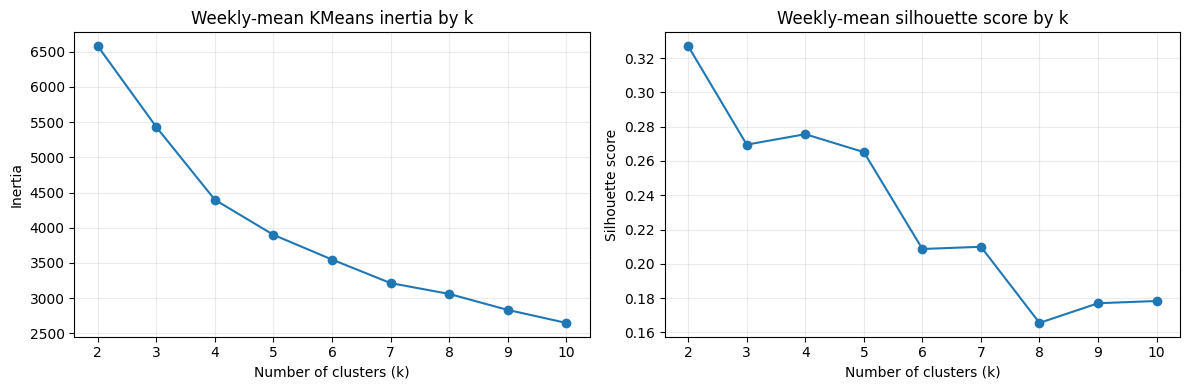

,k,inertia,silhouette_score
0,2,6577.178608,0.326936
1,3,5428.839498,0.269531
2,4,4396.631499,0.275609
3,5,3899.628557,0.265160
4,6,3548.782196,0.208678
5,7,3214.864798,0.209970
6,8,3061.326180,0.165590
7,9,2834.352465,0.177048
8,10,2650.018810,0.178358


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

WEEKLY_MEAN_PCA_COMPONENTS = 10
WEEKLY_MEAN_K_VALUES = range(2, 11)

weekly_mean_scaler = StandardScaler()
X_weekly_mean = weekly_mean_scaler.fit_transform(weekly_mean_features_for_clustering)

weekly_mean_pca = PCA(n_components=WEEKLY_MEAN_PCA_COMPONENTS, random_state=32)
weekly_mean_pca_scores = weekly_mean_pca.fit_transform(X_weekly_mean)

weekly_mean_k_diagnostics = []
for k in WEEKLY_MEAN_K_VALUES:
    model = KMeans(n_clusters=k, random_state=32, n_init=20)
    labels = model.fit_predict(weekly_mean_pca_scores)
    weekly_mean_k_diagnostics.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(weekly_mean_pca_scores, labels),
        }
    )

weekly_mean_k_diagnostics = pd.DataFrame(weekly_mean_k_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weekly_mean_k_diagnostics["k"], weekly_mean_k_diagnostics["inertia"], marker="o")
axes[0].set_title("Weekly-mean KMeans inertia by k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.25)

axes[1].plot(weekly_mean_k_diagnostics["k"], weekly_mean_k_diagnostics["silhouette_score"], marker="o")
axes[1].set_title("Weekly-mean silhouette score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

display(weekly_mean_k_diagnostics)

In [36]:
WEEKLY_MEAN_N_CLUSTERS = 3

weekly_mean_cluster_model = KMeans(
    n_clusters=WEEKLY_MEAN_N_CLUSTERS,
    random_state=32,
    n_init=20,
)
weekly_mean_cluster_labels = weekly_mean_cluster_model.fit_predict(weekly_mean_pca_scores)

weekly_mean_cluster_assignments = pd.DataFrame(
    {
        "ee_site_id": weekly_mean_features_for_clustering.index,
        "weekly_mean_cluster": weekly_mean_cluster_labels,
    }
).set_index("ee_site_id")

print(
    f"Clustered {len(weekly_mean_cluster_assignments):,} sites using "
    f"{WEEKLY_MEAN_PCA_COMPONENTS} weekly-mean PCA dimensions and "
    f"{WEEKLY_MEAN_N_CLUSTERS} clusters."
)
display(weekly_mean_cluster_assignments["weekly_mean_cluster"].value_counts().sort_index().rename("n_sites"))

Clustered 220 sites using 10 weekly-mean PCA dimensions and 3 clusters.


weekly_mean_cluster
0    104
1     74
2     42
Name: n_sites, dtype: int64

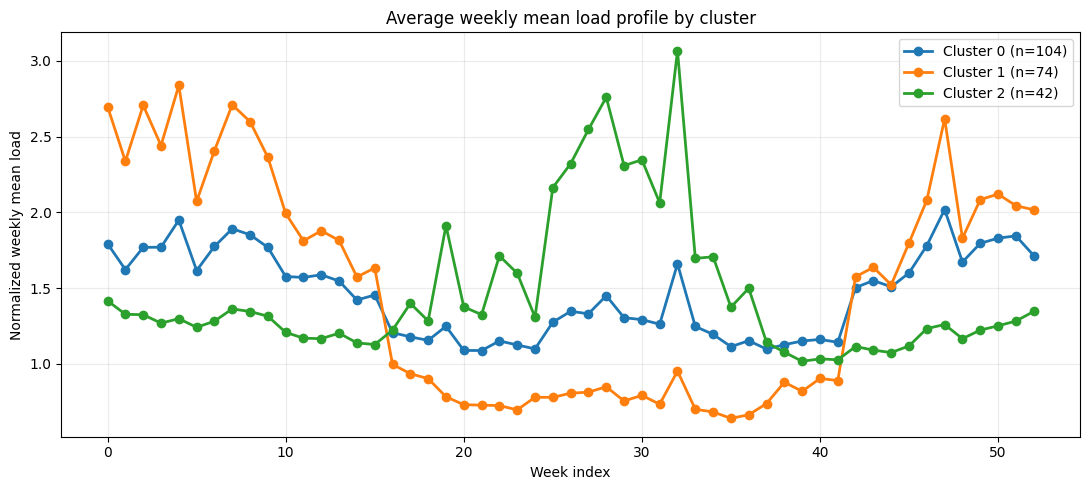

In [37]:
weekly_mean_cluster_profiles = weekly_mean_features_for_clustering.join(weekly_mean_cluster_assignments)
weekly_mean_cluster_average = weekly_mean_cluster_profiles.groupby("weekly_mean_cluster").mean()
weekly_mean_cluster_counts = weekly_mean_cluster_assignments["weekly_mean_cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
weeks = np.arange(weekly_mean_cluster_average.shape[1])
for cluster_id, profile in weekly_mean_cluster_average.iterrows():
    ax.plot(
        weeks,
        profile.values,
        marker="o",
        linewidth=2,
        label=f"Cluster {cluster_id} (n={weekly_mean_cluster_counts.loc[cluster_id]})",
    )

ax.set_title("Average weekly mean load profile by cluster")
ax.set_xlabel("Week index")
ax.set_ylabel("Normalized weekly mean load")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Combined Cluster Category Export

Combine the typical-day cluster and weekly-mean cluster into a single category for each site and save the assignments to CSV.

In [38]:
COMBINED_CLUSTER_CATEGORY_PATH = Path("../src/data/sites/typical_day_weekly_cluster_categories.csv")

combined_cluster_categories = (
    typical_day_cluster_assignments
    .join(weekly_mean_cluster_assignments, how="inner")
    .reset_index()
)
combined_cluster_categories["combined_cluster_category"] = (
    "typical_"
    + combined_cluster_categories["typical_day_cluster"].astype(str)
    + "__weekly_"
    + combined_cluster_categories["weekly_mean_cluster"].astype(str)
)
combined_cluster_categories["combined_cluster_id"] = pd.factorize(
    combined_cluster_categories["combined_cluster_category"],
    sort=True,
)[0]

combined_cluster_categories.to_csv(COMBINED_CLUSTER_CATEGORY_PATH, index=False)

print(f"Saved {len(combined_cluster_categories):,} site cluster categories to {COMBINED_CLUSTER_CATEGORY_PATH}")
display(
    combined_cluster_categories["combined_cluster_category"]
    .value_counts()
    .sort_index()
    .rename("n_sites")
)

Saved 218 site cluster categories to ..\src\data\sites\typical_day_weekly_cluster_categories.csv


combined_cluster_category
typical_0__weekly_0     3
typical_0__weekly_1     4
typical_0__weekly_2     1
typical_1__weekly_0    54
typical_1__weekly_1    42
typical_1__weekly_2    10
typical_2__weekly_0    24
typical_2__weekly_1     4
typical_2__weekly_2    27
typical_3__weekly_0    21
typical_3__weekly_1    24
typical_3__weekly_2     4
Name: n_sites, dtype: int64

## Change-Point Weather Response Analysis

Fit a two-sided change-point model for each home to describe how weekly mean load changes with outdoor temperature. The model assumes a flat baseload in the middle temperature range, plus a heating response below a heating change point and a cooling response above a cooling change point.

For weekly mean load $ and weekly mean outdoor temperature $, fit:

L = B + m_h \\max(H - T, 0) + m_c \\max(T - C, 0)

where:

- $ is the baseload.
- $ is the heating change point.
- $ is the cooling change point.
- $ is the heating slope, or load increase per degree below $.
- $ is the cooling slope, or load increase per degree above $.

The fit uses the **unnormalized cleaned hourly load** from calculated_overall_hourly_kept, aggregated to weekly mean load. Weather inputs come from alidation/src/data/weather, and the site-to-weather-file mapping comes from alidation/src/data/metadata/SITES v9.2.csv.

In [40]:


CHANGE_POINT_METADATA_PATH = Path("../src/data/metadata/SITES v9.2.csv")
CHANGE_POINT_WEATHER_DIR = Path("../src/data/weather")


def normalize_station_id(station_id):
    if pd.isna(station_id):
        return np.nan
    station_id = str(station_id).strip()
    if "-" not in station_id:
        return station_id
    usaf, wban = station_id.split("-", 1)
    if wban.isdigit():
        return f"{usaf}-{int(wban):05d}"
    return station_id


def read_epw_hourly_temperature(weather_path):
    epw = pd.read_csv(weather_path, skiprows=8, header=None)
    weather = pd.DataFrame(
        {
            "year": epw.iloc[:, 0].astype(int),
            "month": epw.iloc[:, 1].astype(int),
            "day": epw.iloc[:, 2].astype(int),
            "hour": epw.iloc[:, 3].astype(int),
            "outdoor_temp_c": pd.to_numeric(epw.iloc[:, 6], errors="coerce"),
        }
    )
    weather["local_time"] = pd.to_datetime(
        weather[["year", "month", "day"]]
    ) + pd.to_timedelta(weather["hour"] - 1, unit="h")
    return weather[["local_time", "outdoor_temp_c"]]


site_weather_metadata = pd.read_csv(
    CHANGE_POINT_METADATA_PATH,
    dtype={"ee_site_id": str, "station_id": str},
)
site_weather_metadata["ee_site_id"] = site_weather_metadata["ee_site_id"].astype(str)
site_weather_metadata["station_id"] = site_weather_metadata["station_id"].map(normalize_station_id)
site_weather_metadata["tz_utc_offset"] = pd.to_numeric(site_weather_metadata["tz_utc_offset"], errors="coerce")
site_weather_metadata = site_weather_metadata[["ee_site_id", "station_id", "tz_utc_offset"]].drop_duplicates("ee_site_id")

weekly_load_for_change_point = calculated_overall_hourly_kept.copy()
weekly_load_for_change_point["ee_site_id"] = weekly_load_for_change_point["ee_site_id"].astype(str)
weekly_load_for_change_point = weekly_load_for_change_point.merge(site_weather_metadata, on="ee_site_id", how="left")
weekly_load_for_change_point["local_time"] = (
    weekly_load_for_change_point["min_t"]
    + pd.to_timedelta(weekly_load_for_change_point["tz_utc_offset"].fillna(0), unit="h")
)
weekly_load_for_change_point["week_start"] = weekly_load_for_change_point["local_time"].dt.to_period("W-SUN").dt.start_time

weekly_site_load = (
    weekly_load_for_change_point
    .groupby(["ee_site_id", "station_id", "week_start"], dropna=False)[LOAD_COLUMN]
    .mean()
    .rename("weekly_mean_load")
    .reset_index()
)

weather_cache = {}
for station_id in weekly_site_load["station_id"].dropna().unique():
    weather_path = CHANGE_POINT_WEATHER_DIR / f"{station_id}.epw"
    if weather_path.exists():
        hourly_weather = read_epw_hourly_temperature(weather_path)
        hourly_weather["week_start"] = hourly_weather["local_time"].dt.to_period("W-SUN").dt.start_time
        weather_cache[station_id] = (
            hourly_weather
            .groupby("week_start")["outdoor_temp_c"]
            .mean()
            .rename("weekly_mean_temp_c")
            .reset_index()
        )

weekly_weather_rows = []
for station_id, weekly_weather in weather_cache.items():
    weekly_weather = weekly_weather.copy()
    weekly_weather["station_id"] = station_id
    weekly_weather_rows.append(weekly_weather)

weekly_weather = pd.concat(weekly_weather_rows, ignore_index=True) if weekly_weather_rows else pd.DataFrame(
    columns=["week_start", "weekly_mean_temp_c", "station_id"]
)

weekly_change_point_data = weekly_site_load.merge(
    weekly_weather,
    on=["station_id", "week_start"],
    how="inner",
)

print(
    f"Prepared weekly load-weather data for {weekly_change_point_data['ee_site_id'].nunique():,} sites "
    f"across {weekly_change_point_data['station_id'].nunique():,} weather stations."
)

Prepared weekly load-weather data for 220 sites across 54 weather stations.


In [49]:
HEATING_CHANGE_POINT_GRID_C = np.arange(5.0, 20.5, 0.5)
COOLING_CHANGE_POINT_GRID_C = np.arange(15.0, 30.5, 0.5)
MIN_WEEKLY_POINTS_FOR_CHANGE_POINT = 20
MIN_CHANGE_POINT_DEADBAND_C = 1.0


def fit_two_sided_change_point(site_weekly):
    site_weekly = site_weekly.dropna(subset=["weekly_mean_load", "weekly_mean_temp_c"])
    if len(site_weekly) < MIN_WEEKLY_POINTS_FOR_CHANGE_POINT:
        return None

    temp = site_weekly["weekly_mean_temp_c"].to_numpy()
    load = site_weekly["weekly_mean_load"].to_numpy()
    load_mean = load.mean()
    total_ss = np.sum((load - load_mean) ** 2)

    best_fit = None
    for heating_cp in HEATING_CHANGE_POINT_GRID_C:
        for cooling_cp in COOLING_CHANGE_POINT_GRID_C:
            if cooling_cp - heating_cp < MIN_CHANGE_POINT_DEADBAND_C:
                continue
            design = np.column_stack(
                [
                    np.ones_like(temp),
                    np.maximum(heating_cp - temp, 0),
                    np.maximum(temp - cooling_cp, 0),
                ]
            )
            coefficients, _ = nnls(design, load)
            predicted = design @ coefficients
            residual_ss = np.sum((load - predicted) ** 2)
            r2 = 1 - residual_ss / total_ss if total_ss > 0 else np.nan

            if best_fit is None or residual_ss < best_fit["residual_ss"]:
                best_fit = {
                    "heating_change_point_c": heating_cp,
                    "cooling_change_point_c": cooling_cp,
                    "baseload": coefficients[0],
                    "heating_slope": coefficients[1],
                    "cooling_slope": coefficients[2],
                    "r2": r2,
                    "residual_ss": residual_ss,
                    "n_weeks": len(site_weekly),
                }

    return best_fit


change_point_fit_rows = []
for site_id, site_weekly in weekly_change_point_data.groupby("ee_site_id"):
    fit = fit_two_sided_change_point(site_weekly)
    if fit is None:
        continue
    fit["ee_site_id"] = site_id
    fit["station_id"] = site_weekly["station_id"].iloc[0]
    change_point_fit_rows.append(fit)

change_point_fit_summary = pd.DataFrame(change_point_fit_rows)
change_point_fit_summary = change_point_fit_summary[
    [
        "ee_site_id",
        "station_id",
        "n_weeks",
        "heating_change_point_c",
        "cooling_change_point_c",
        "baseload",
        "heating_slope",
        "cooling_slope",
        "r2",
        "residual_ss",
    ]
]

print(f"Fit change-point models for {len(change_point_fit_summary):,} sites.")

Fit change-point models for 212 sites.


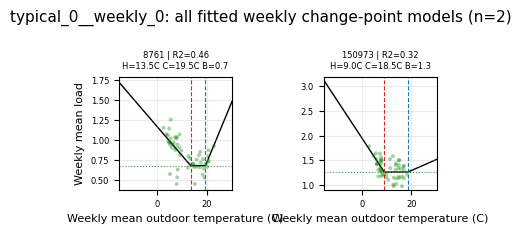

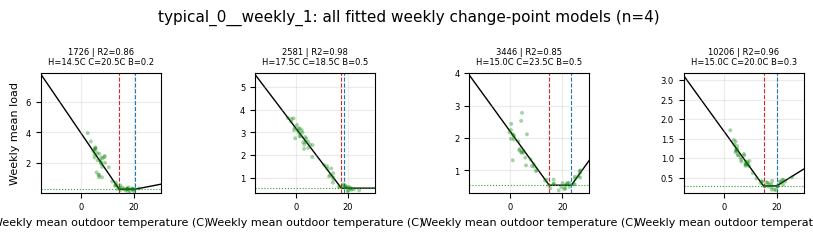

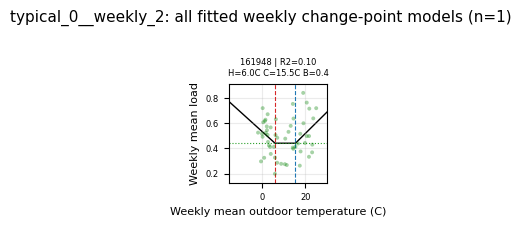

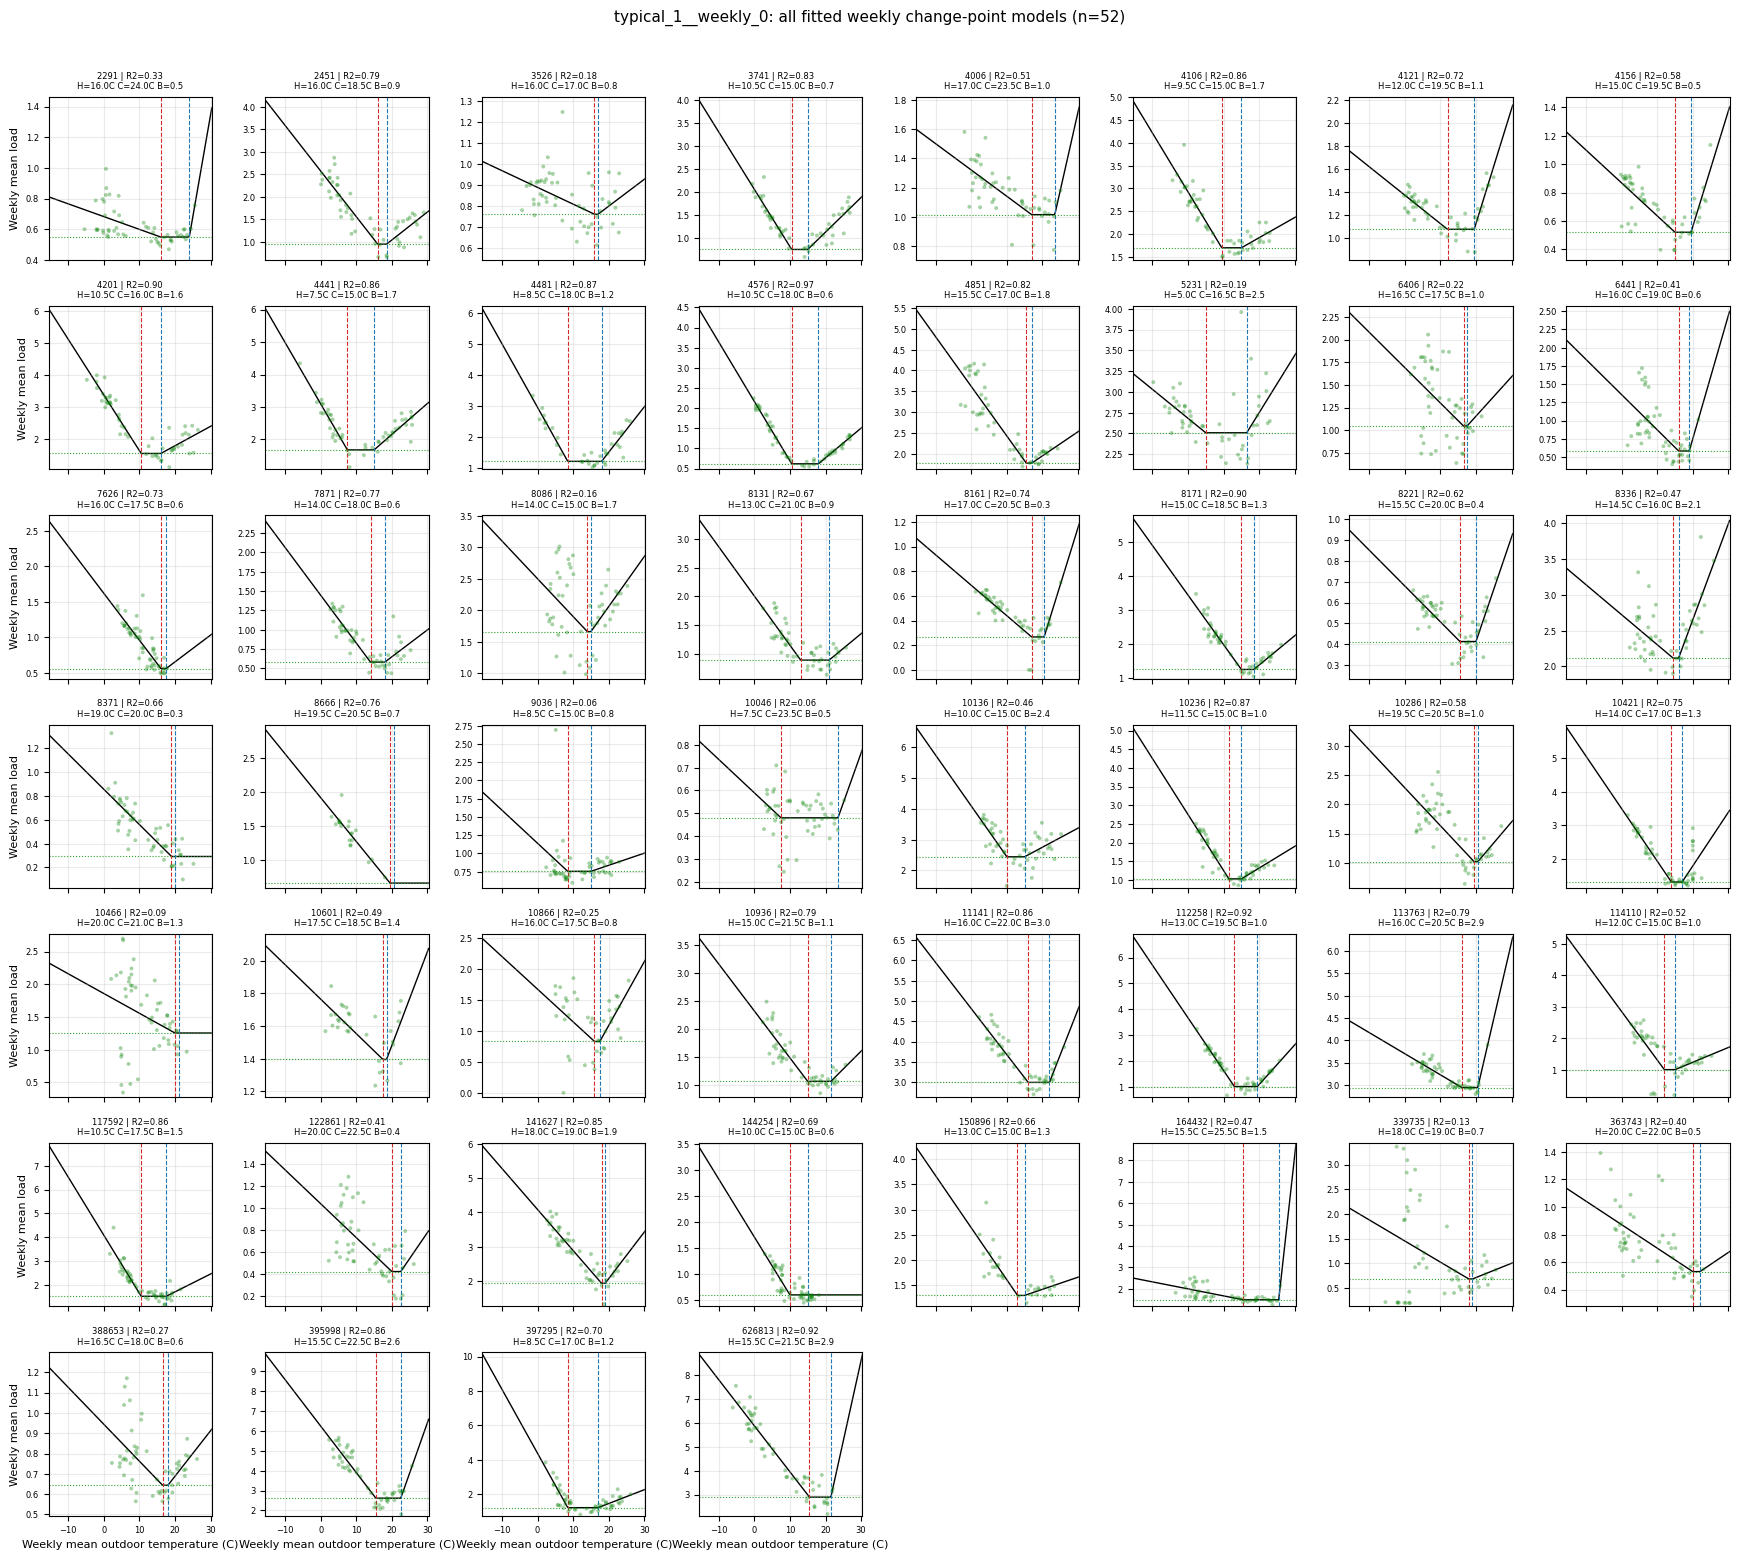

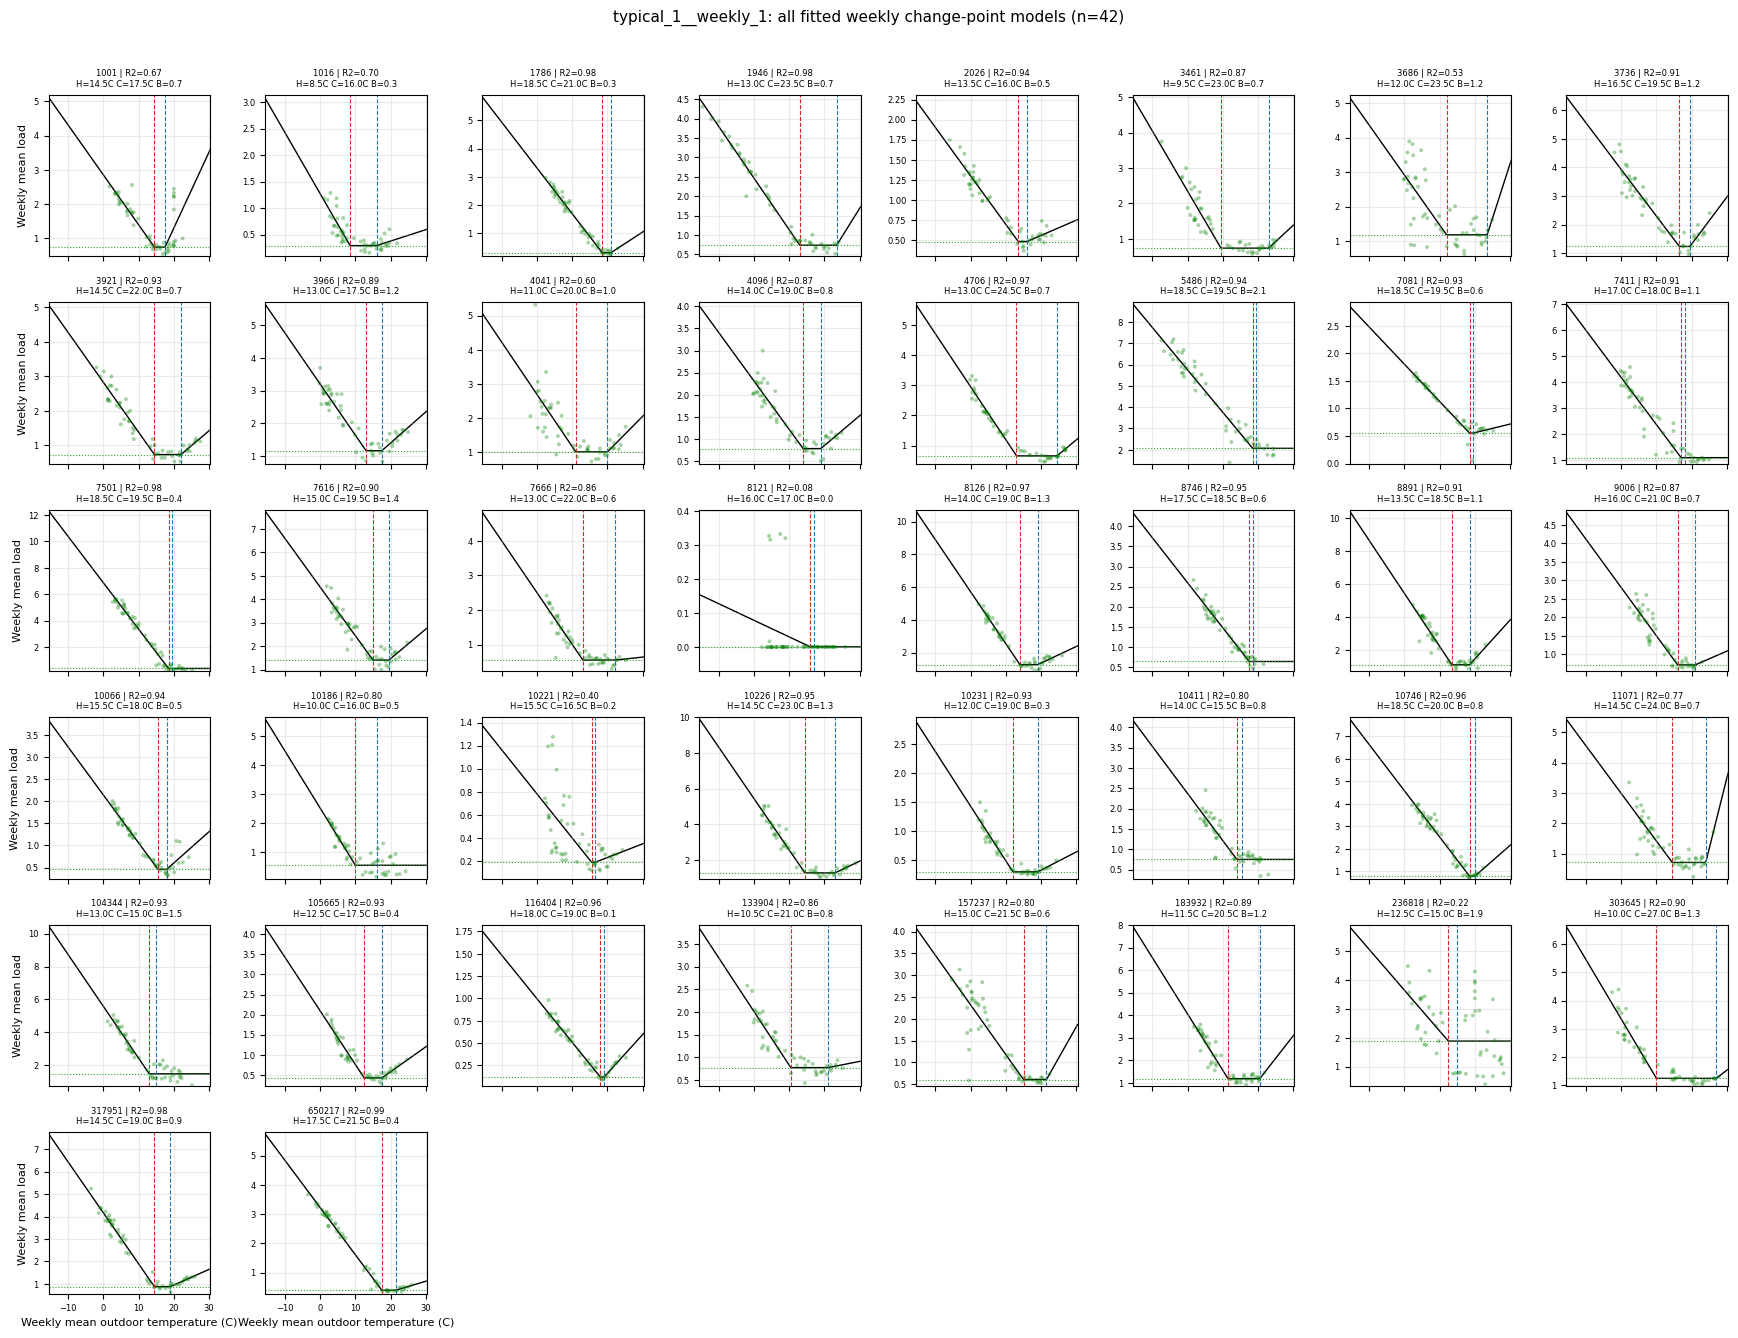

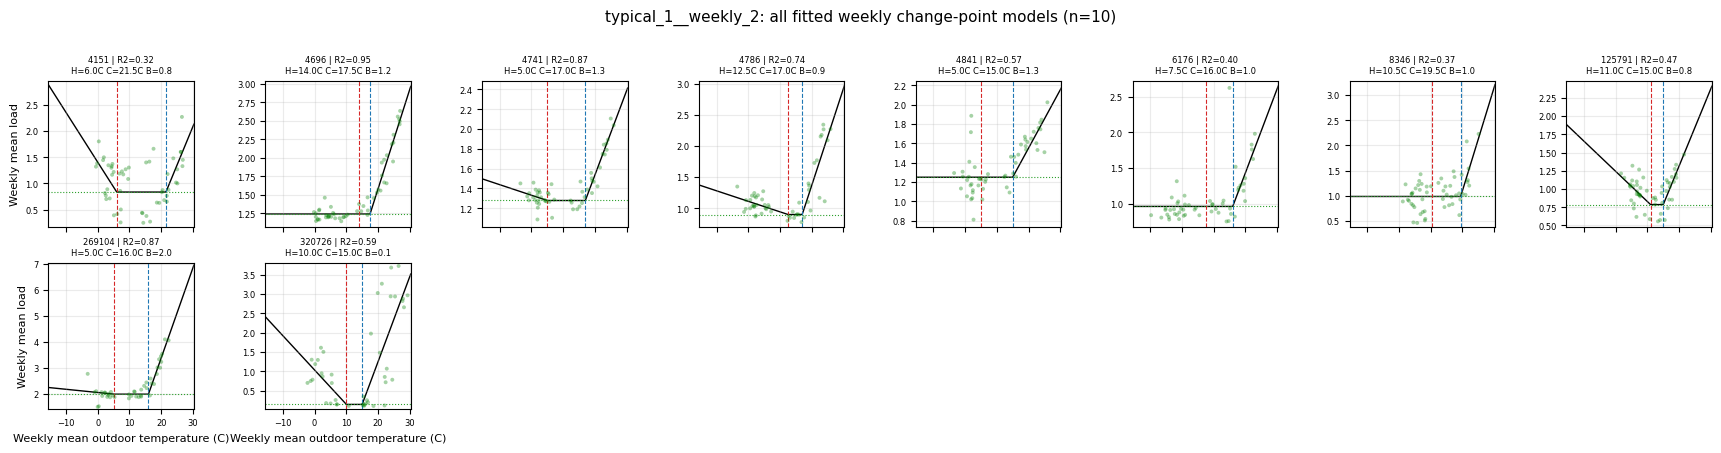

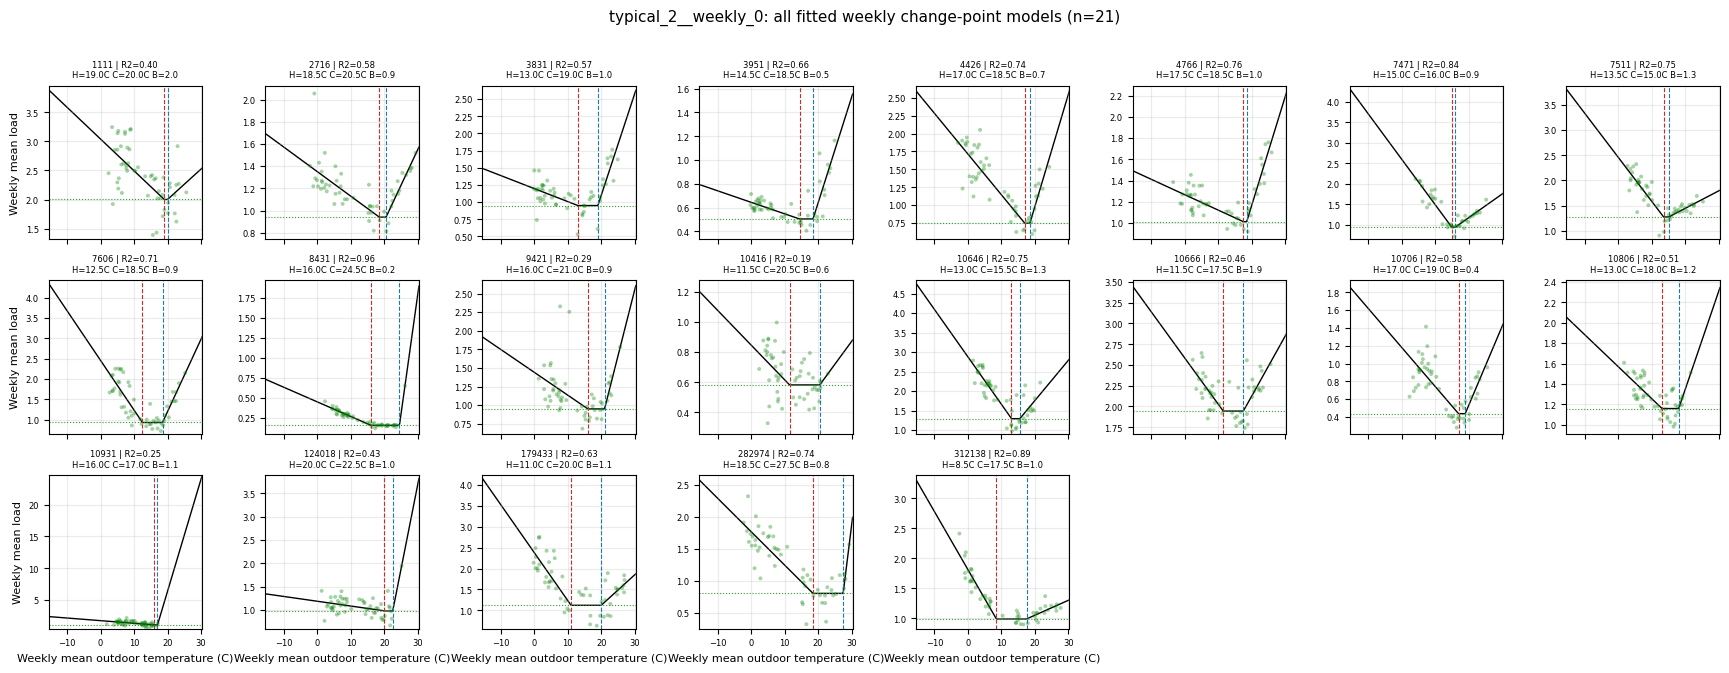

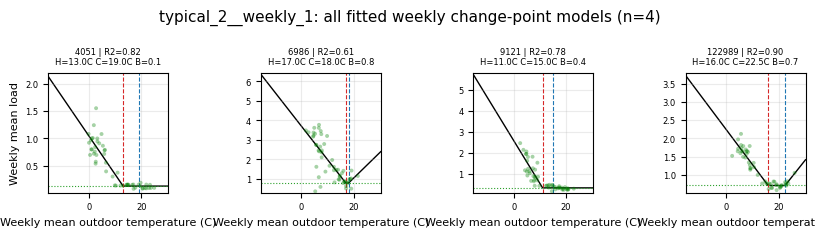

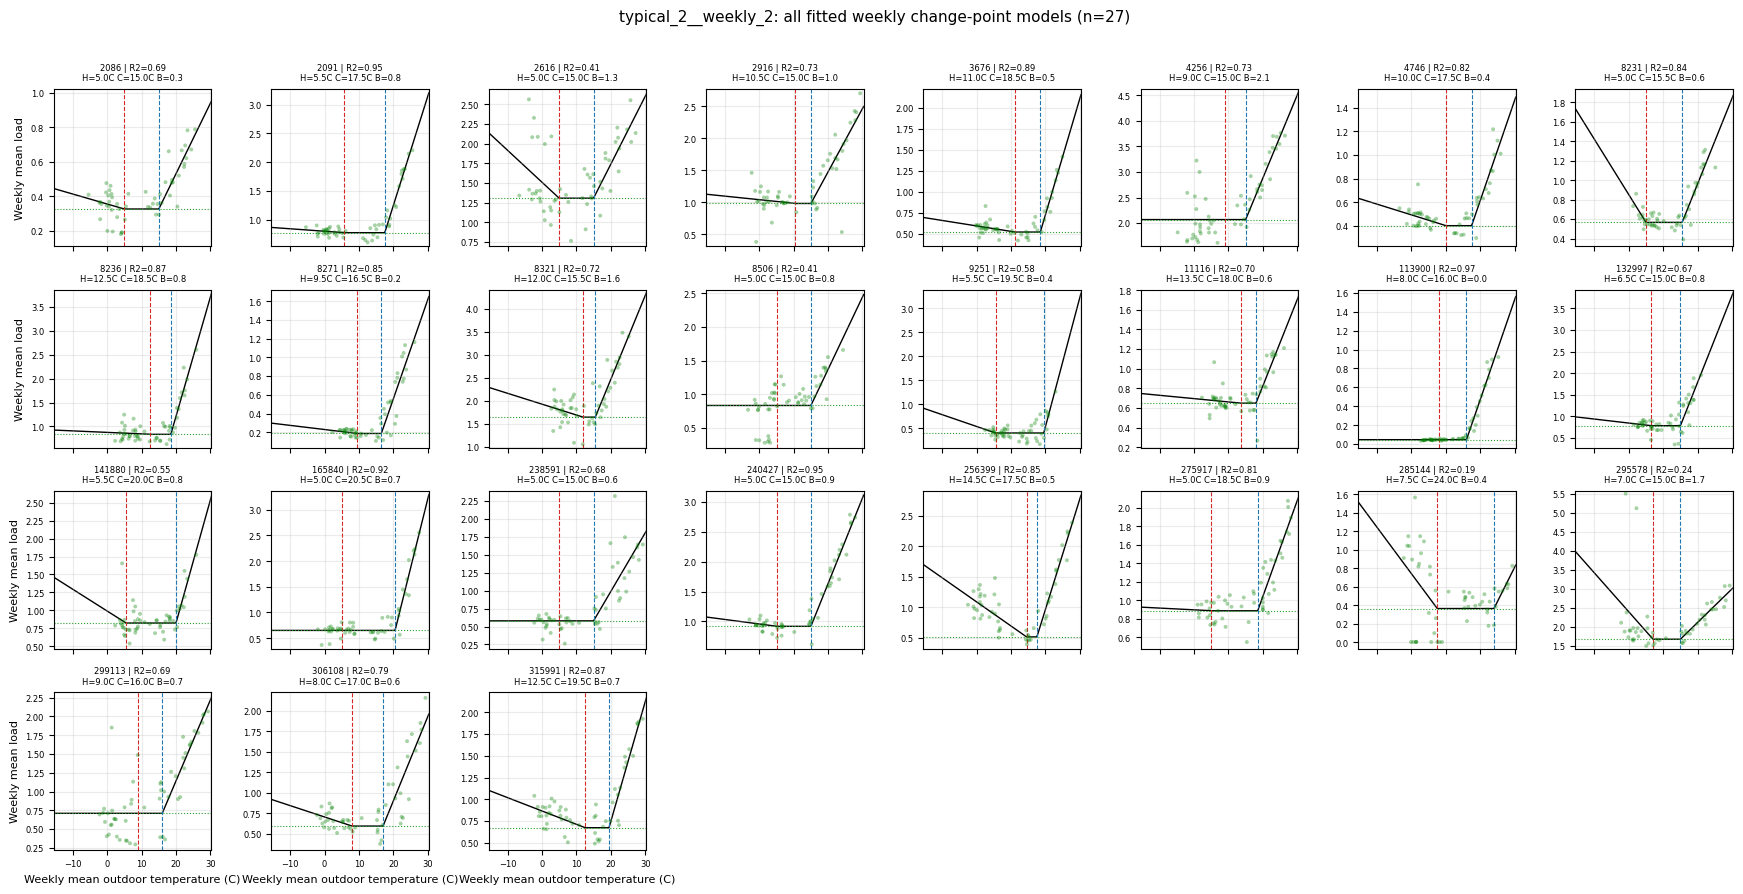

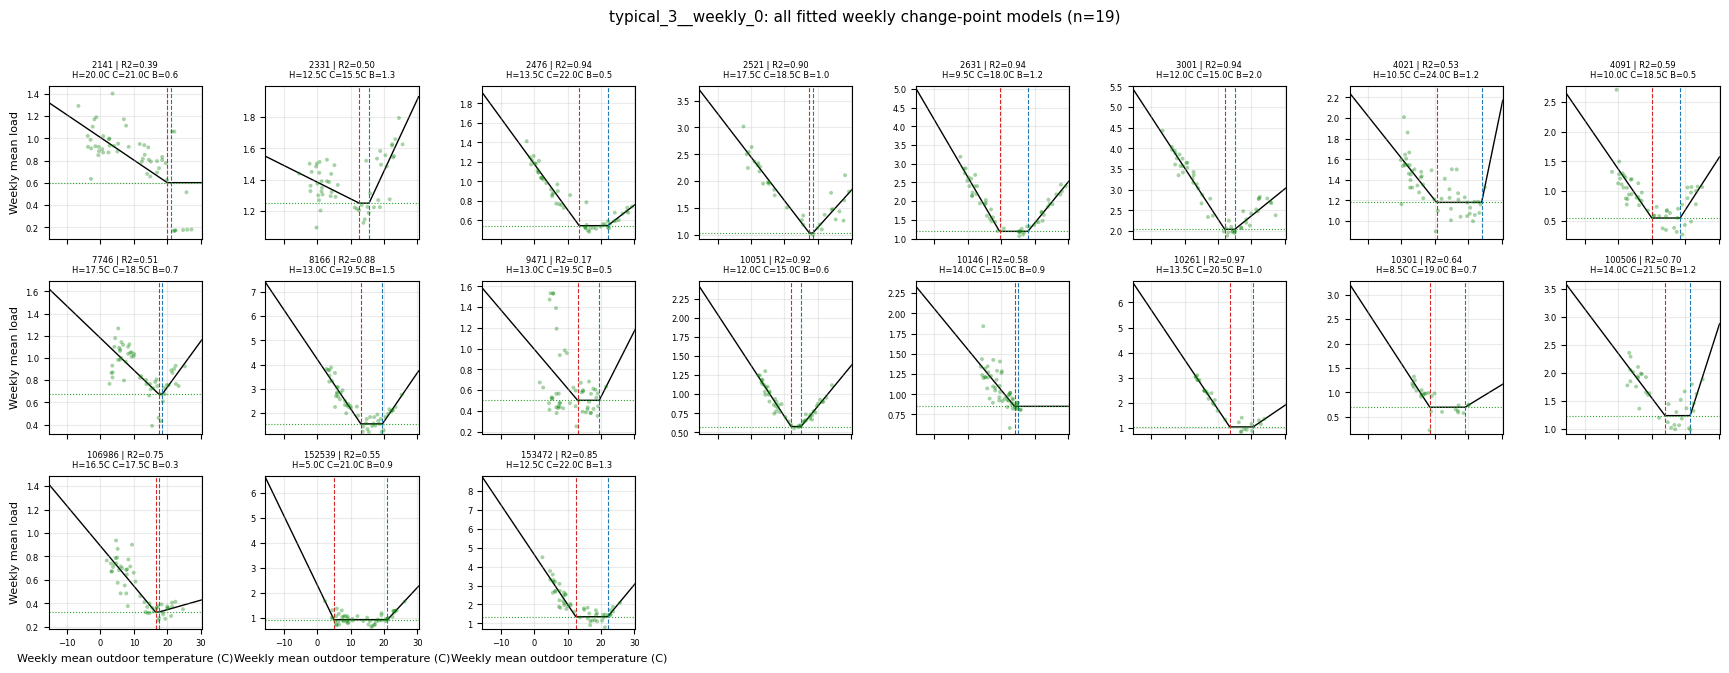

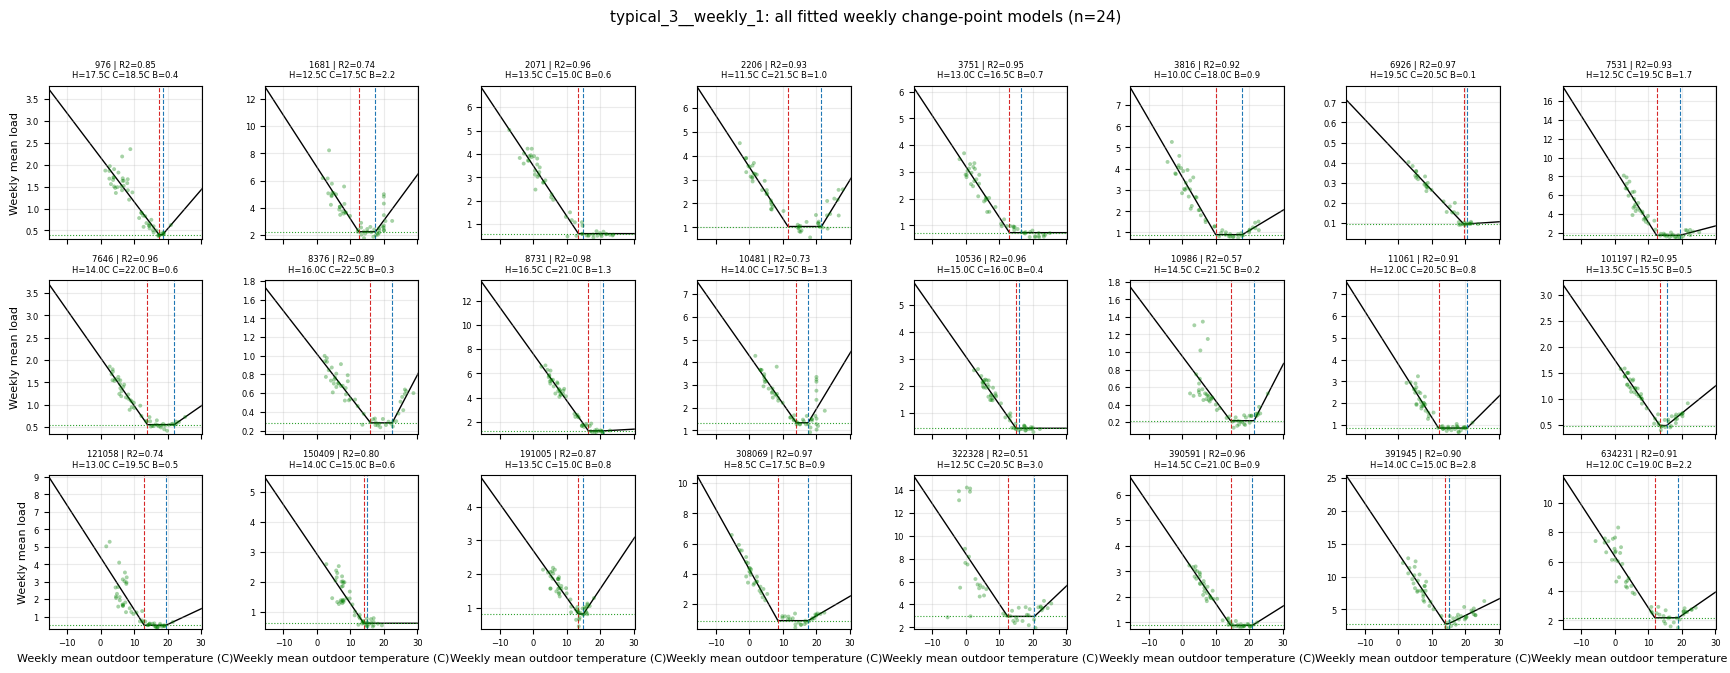

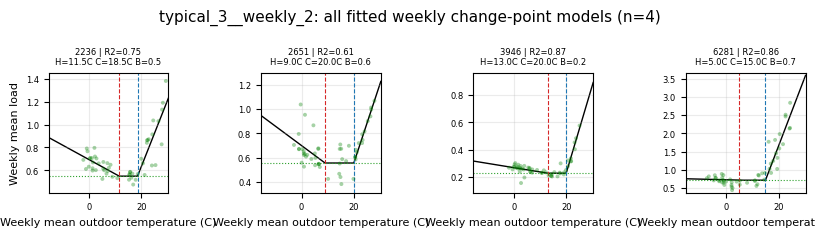

In [54]:
plot_weekly_change_point_data = weekly_change_point_data.copy()
plot_weekly_change_point_data["ee_site_id"] = plot_weekly_change_point_data["ee_site_id"].astype(str)
plot_weekly_change_point_data["station_id"] = plot_weekly_change_point_data["station_id"].astype(str)

plot_combined_cluster_categories = combined_cluster_categories[[
    "ee_site_id",
    "combined_cluster_category",
    "combined_cluster_id",
]].copy()
plot_combined_cluster_categories["ee_site_id"] = plot_combined_cluster_categories["ee_site_id"].astype(str)

plot_change_point_fit_summary = change_point_fit_summary.copy()
plot_change_point_fit_summary["ee_site_id"] = plot_change_point_fit_summary["ee_site_id"].astype(str)
plot_change_point_fit_summary["station_id"] = plot_change_point_fit_summary["station_id"].astype(str)

plot_change_point_data = (
    plot_weekly_change_point_data
    .merge(plot_combined_cluster_categories, on="ee_site_id", how="inner")
    .merge(plot_change_point_fit_summary, on=["ee_site_id", "station_id"], how="inner")
)

x_min = plot_change_point_data["weekly_mean_temp_c"].min()
x_max = plot_change_point_data["weekly_mean_temp_c"].max()
x_pad = max((x_max - x_min) * 0.02, 1.0)
x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 200)

y_min = plot_change_point_data["weekly_mean_load"].min()
y_max = plot_change_point_data["weekly_mean_load"].max()
y_pad = max((y_max - y_min) * 0.02, 0.1)

category_order = sorted(plot_change_point_data["combined_cluster_category"].dropna().unique())
SMALL_MULTIPLE_COLS = 8
SMALL_MULTIPLE_SIZE = (2.2, 2.2)

for category in category_order:
    category_data = plot_change_point_data[plot_change_point_data["combined_cluster_category"] == category]
    site_ids = sorted(category_data["ee_site_id"].unique(), key=lambda value: int(value) if value.isdigit() else value)
    n_sites = len(site_ids)
    n_cols = min(SMALL_MULTIPLE_COLS, n_sites)
    n_rows = int(np.ceil(n_sites / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(SMALL_MULTIPLE_SIZE[0] * n_cols, SMALL_MULTIPLE_SIZE[1] * n_rows),
        sharex=True,
        sharey=False,
        subplot_kw={"box_aspect": 1},
    )
    axes = np.asarray(axes).reshape(-1)

    for ax, site_id in zip(axes, site_ids):
        site_data = category_data[category_data["ee_site_id"] == site_id].sort_values("weekly_mean_temp_c")
        fit = site_data.iloc[0]

        heating_cp = fit["heating_change_point_c"]
        cooling_cp = fit["cooling_change_point_c"]
        baseload = fit["baseload"]
        heating_slope = fit["heating_slope"]
        cooling_slope = fit["cooling_slope"]
        r2 = fit["r2"]

        predicted = (
            baseload
            + heating_slope * np.maximum(heating_cp - x_grid, 0)
            + cooling_slope * np.maximum(x_grid - cooling_cp, 0)
        )

        ax.scatter(
            site_data["weekly_mean_temp_c"],
            site_data["weekly_mean_load"],
            s=8,
            alpha=0.35,
            color="green",
            edgecolor="none",
            zorder=3,
        )
        ax.plot(x_grid, predicted, color="black", linewidth=1, zorder = 1)
        ax.axvline(heating_cp, color="tab:red", linestyle="--", linewidth=0.8)
        ax.axvline(cooling_cp, color="tab:blue", linestyle="--", linewidth=0.8)
        ax.axhline(baseload, color="tab:green", linestyle=":", linewidth=0.8)

        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(
            min(site_data["weekly_mean_load"].min(), predicted.min()) - y_pad * 0.25,
            max(site_data["weekly_mean_load"].max(), predicted.max()) + y_pad * 0.25,
        )
        ax.set_title(
            f"{site_id} | R2={r2:.2f}\nH={heating_cp:.1f}C C={cooling_cp:.1f}C B={baseload:.1f}",
            fontsize=6,
        )
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=6)

    for ax in axes[n_sites:]:
        ax.axis("off")

    for ax in axes[-n_cols:]:
        ax.set_xlabel("Weekly mean outdoor temperature (C)", fontsize=8)
    for row_start in range(0, n_rows * n_cols, n_cols):
        axes[row_start].set_ylabel("Weekly mean load", fontsize=8)

    fig.suptitle(
        f"{category}: all fitted weekly change-point models (n={n_sites})",
        y=1.01,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

## Cluster Geography by County

Map the cluster locations using county and state from alidation/src/data/BEM/rbsa_sites.json. Each county is shown as a pie marker because multiple homes in the same county can belong to different clusters. One map shows weekly-mean clusters, and one map shows typical-day clusters.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


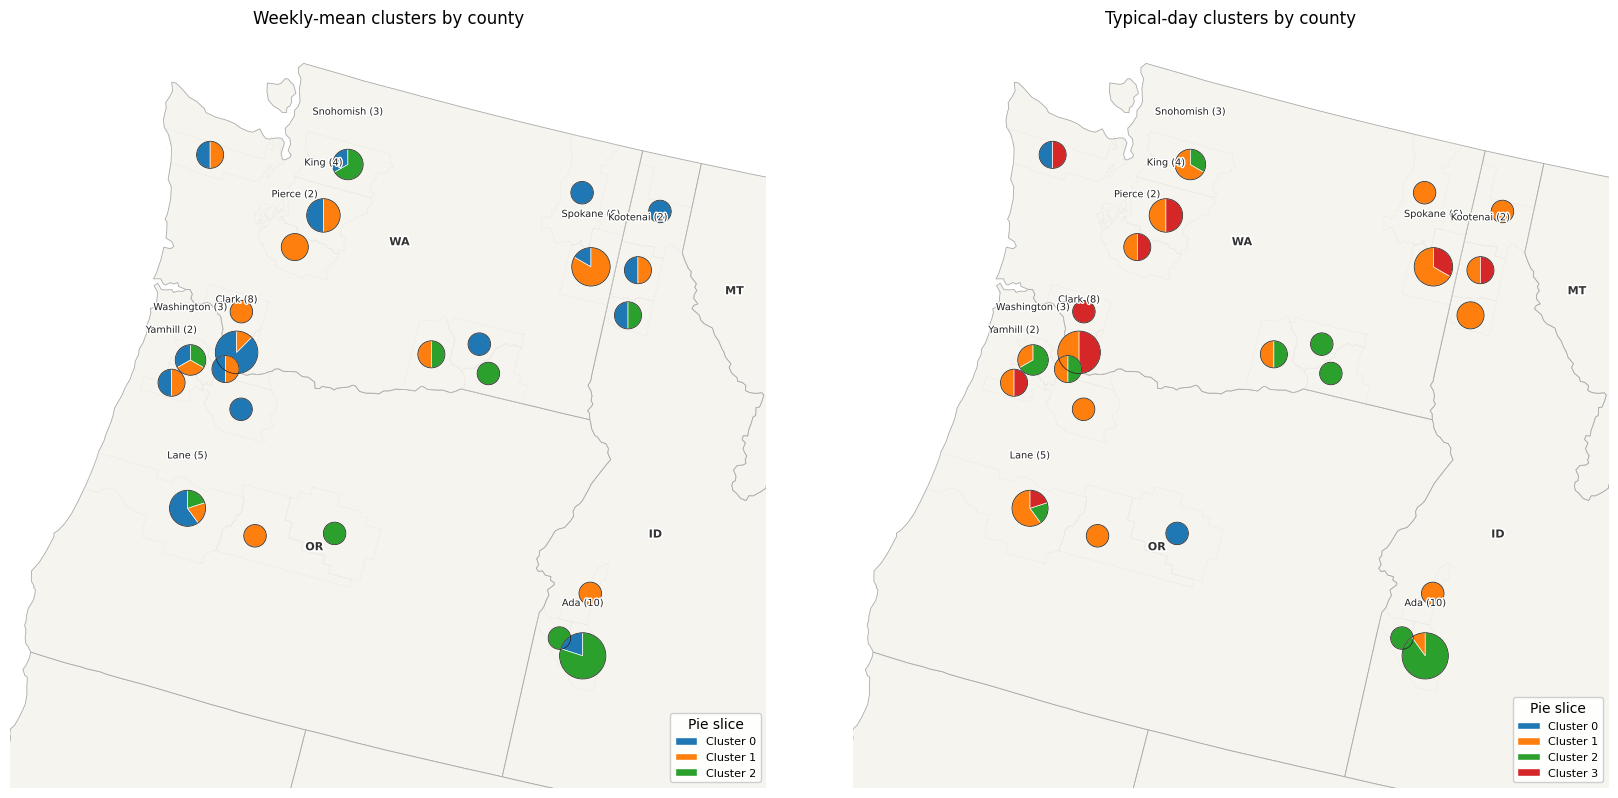

In [64]:
import json
import urllib.request
import zipfile

import geopandas as gpd
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, Patch, Wedge
from shapely.geometry import box

CLUSTER_COUNTY_BEM_PATH = Path("../src/data/BEM/rbsa_sites.json")
CLUSTER_COUNTY_GEO_DIR = Path("../src/data/geo")
CLUSTER_COUNTY_STATE_URL = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip"
CLUSTER_COUNTY_COUNTY_URL = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_500k.zip"
CLUSTER_COUNTY_PROJ_CRS = "EPSG:5070"


def normalize_map_site_id(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text


def normalize_county_name(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper()
    for suffix in [" COUNTY", " PARISH", " BOROUGH", " CENSUS AREA"]:
        if text.endswith(suffix):
            text = text[: -len(suffix)]
    return " ".join(text.split())


def download_and_extract_zip(url, cache_dir):
    cache_dir.mkdir(parents=True, exist_ok=True)
    zip_path = cache_dir / url.rsplit("/", 1)[-1]
    extract_dir = cache_dir / zip_path.stem

    if not zip_path.exists():
        print(f"Downloading {zip_path.name}...")
        with urllib.request.urlopen(url, timeout=60) as response:
            zip_path.write_bytes(response.read())

    if not extract_dir.exists() or not any(extract_dir.iterdir()):
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(extract_dir)

    return extract_dir


def load_census_shapefile(url, cache_dir):
    extract_dir = download_and_extract_zip(url, cache_dir)
    return gpd.read_file(next(extract_dir.glob("*.shp")))


def draw_county_cluster_pie(ax, x, y, counts, radius, colors):
    total = counts.sum()
    if total <= 0:
        return

    start = 90
    for cluster_id, count in counts[counts > 0].items():
        sweep = 360 * count / total
        ax.add_patch(
            Wedge(
                (x, y),
                radius,
                start,
                start + sweep,
                facecolor=colors[cluster_id],
                edgecolor="white",
                linewidth=0.45,
                zorder=5,
            )
        )
        start += sweep

    ax.add_patch(Circle((x, y), radius, facecolor="none", edgecolor="#222222", linewidth=0.55, zorder=6))


def build_county_cluster_geo(site_clusters, cluster_column, counties):
    county_cluster_counts = pd.crosstab(
        [site_clusters["bem_state"], site_clusters["bem_county_norm"]],
        site_clusters[cluster_column],
    ).reset_index()
    county_cluster_counts["n_sites"] = county_cluster_counts.drop(columns=["bem_state", "bem_county_norm"]).sum(axis=1)

    county_cluster_geo = counties.merge(
        county_cluster_counts,
        left_on=["STUSPS", "county_norm"],
        right_on=["bem_state", "bem_county_norm"],
        how="inner",
    )
    county_cluster_geo["plot_point"] = county_cluster_geo.geometry.representative_point()
    county_cluster_geo["x"] = county_cluster_geo["plot_point"].x
    county_cluster_geo["y"] = county_cluster_geo["plot_point"].y
    cluster_columns = [column for column in county_cluster_counts.columns if column not in ["bem_state", "bem_county_norm", "n_sites"]]
    return county_cluster_geo, cluster_columns


def plot_county_cluster_map(ax, county_cluster_geo, cluster_columns, title, states, data_states):
    states.plot(ax=ax, color="#f6f4ee", edgecolor="#aaaaaa", linewidth=0.6, zorder=1)
    county_cluster_geo.boundary.plot(ax=ax, color="#dddddd", linewidth=0.35, alpha=0.45, zorder=2)

    x_min, y_min, x_max, y_max = county_cluster_geo.total_bounds
    pad = 90_000
    view_poly = box(x_min - pad, y_min - pad, x_max + pad, y_max + pad)

    for _, row in states[states["STUSPS"].isin(data_states)].iterrows():
        clipped = row.geometry.intersection(view_poly)
        if clipped.is_empty:
            continue
        ax.text(
            clipped.centroid.x,
            clipped.centroid.y,
            row["STUSPS"],
            ha="center",
            va="center",
            fontsize=8,
            color="#333333",
            fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
            zorder=4,
        )

    cluster_columns = sorted(cluster_columns)
    cluster_colors = {cluster_id: plt.get_cmap("tab10")(i % 10) for i, cluster_id in enumerate(cluster_columns)}
    max_county_sites = county_cluster_geo["n_sites"].max()

    for _, row in county_cluster_geo.iterrows():
        radius = 7_000 + 21_000 * np.sqrt(row["n_sites"] / max_county_sites)
        draw_county_cluster_pie(ax, row["x"], row["y"], row[cluster_columns], radius, cluster_colors)

    for _, row in county_cluster_geo.sort_values("n_sites", ascending=False).head(10).iterrows():
        ax.text(
            row["x"],
            row["y"] + 58_000,
            f"{row['NAME']} ({int(row['n_sites'])})",
            ha="center",
            va="bottom",
            fontsize=7,
            color="#222222",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
            zorder=7,
        )

    handles = [Patch(facecolor=cluster_colors[cluster_id], edgecolor="white", label=f"Cluster {cluster_id}") for cluster_id in cluster_columns]
    ax.legend(handles=handles, title="Pie slice", loc="lower right", framealpha=0.92, fontsize=8)

    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_axis_off()
    ax.set_aspect("equal")


with open(CLUSTER_COUNTY_BEM_PATH, encoding="utf-8") as f:
    rbsa_sites_for_map = json.load(f)

bem_county_location = pd.DataFrame(
    [
        {
            "ee_site_id": normalize_map_site_id(site.get("info", {}).get("ee_site_id")),
            "bem_state": site.get("info", {}).get("state"),
            "bem_county_norm": normalize_county_name(site.get("info", {}).get("county")),
        }
        for site in rbsa_sites_for_map
    ]
).drop_duplicates("ee_site_id")

weekly_map_clusters = weekly_mean_cluster_assignments.reset_index().copy()
weekly_map_clusters["ee_site_id"] = weekly_map_clusters["ee_site_id"].map(normalize_map_site_id)
weekly_map_clusters = weekly_map_clusters.merge(bem_county_location, on="ee_site_id", how="left").dropna(subset=["bem_state", "bem_county_norm"])

typical_day_map_clusters = typical_day_cluster_assignments.reset_index().copy()
typical_day_map_clusters["ee_site_id"] = typical_day_map_clusters["ee_site_id"].map(normalize_map_site_id)
typical_day_map_clusters = typical_day_map_clusters.merge(bem_county_location, on="ee_site_id", how="left").dropna(subset=["bem_state", "bem_county_norm"])

states = load_census_shapefile(CLUSTER_COUNTY_STATE_URL, CLUSTER_COUNTY_GEO_DIR)
states = states[~states["STUSPS"].isin(["AK", "HI", "PR", "VI", "GU", "MP", "AS"])].to_crs(CLUSTER_COUNTY_PROJ_CRS)

counties = load_census_shapefile(CLUSTER_COUNTY_COUNTY_URL, CLUSTER_COUNTY_GEO_DIR)
counties["county_norm"] = counties["NAME"].map(normalize_county_name)
counties = counties[counties["STUSPS"].isin(bem_county_location["bem_state"].dropna().unique())].to_crs(CLUSTER_COUNTY_PROJ_CRS)

weekly_county_geo, weekly_cluster_columns = build_county_cluster_geo(weekly_map_clusters, "weekly_mean_cluster", counties)
typical_county_geo, typical_cluster_columns = build_county_cluster_geo(typical_day_map_clusters, "typical_day_cluster", counties)

data_states = set(bem_county_location["bem_state"].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(17, 8), subplot_kw={"box_aspect": 1})
plot_county_cluster_map(
    axes[0],
    weekly_county_geo,
    weekly_cluster_columns,
    "Weekly-mean clusters by county",
    states,
    data_states,
)
plot_county_cluster_map(
    axes[1],
    typical_county_geo,
    typical_cluster_columns,
    "Typical-day clusters by county",
    states,
    data_states,
)
plt.tight_layout()
plt.show()